In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
from matplotlib import pyplot as plt
from scipy import stats

In [3]:
data = pd.read_csv(r"C:\Users\DELL\Desktop\Alz\Alzheimer-s-Disease\alzheimers_disease_data.csv")

In [4]:
data.drop(columns=["PatientID",'DoctorInCharge'] , inplace=True)

In [5]:
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       401
           1       0.80      0.66      0.72       244

    accuracy                           0.81       645
   macro avg       0.81      0.78      0.79       645
weighted avg       0.81      0.81      0.80       645



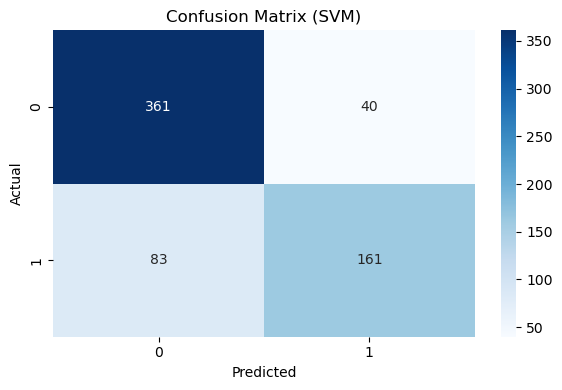

Accuracy: 0.8093
F1 Score: 0.7236


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ===============================
# 2. Feature Scaling
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 3. Train SVM Classifier
# ===============================
model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
model.fit(X_train_scaled, y_train)

# ===============================
# 4. Predict
# ===============================
y_pred = model.predict(X_test_scaled)

# ===============================
# 5. Classification Report
# ===============================
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 6. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.tight_layout()
plt.show()

# ===============================
# 7. Accuracy and F1 Score
# ===============================
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


In [7]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

# Start time
start_time = time.time()
brf = BalancedRandomForestClassifier(random_state=42)
scores = cross_val_score(brf, X, y, cv=5, scoring='f1')
# End time
end_time = time.time()

print("⏱ Total Training Time (seconds):", round(end_time - start_time, 3))
print("⏱ Total Training Time (minutes):", round((end_time - start_time)/60, 3))

print("F1 scores:", scores)
print("Mean F1:", scores.mean())


⏱ Total Training Time (seconds): 1.678
⏱ Total Training Time (minutes): 0.028
F1 scores: [0.97385621 0.96794872 0.95737705 0.98013245 0.69372694]
Mean F1: 0.9146082727759742


⏱ Total Training Time (seconds): 0.262
⏱ Total Training Time (minutes): 0.004
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       401
           1       0.95      0.89      0.92       244

    accuracy                           0.94       645
   macro avg       0.94      0.93      0.93       645
weighted avg       0.94      0.94      0.94       645



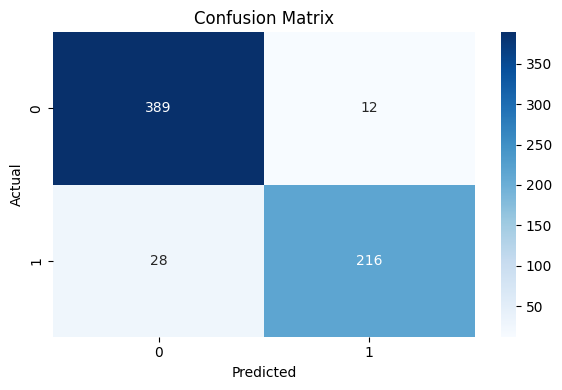

Accuracy: 0.9380
F1 Score: 0.9153


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import time

# Start time
start_time = time.time()
# 4. Train XGBoost Regressor
model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train)
# End time
end_time = time.time()

print("⏱ Total Training Time (seconds):", round(end_time - start_time, 3))
print("⏱ Total Training Time (minutes):", round((end_time - start_time)/60, 3))

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 5. Predict
y_pred = model.predict(X_test_scaled)

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Optional: Print accuracy and F1 Score
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


⏱ Total Training Time (seconds): 106.101
⏱ Total Training Time (minutes): 1.768

SVC Classification Report
              precision    recall  f1-score   support

           0       0.62      1.00      0.77       401
           1       0.00      0.00      0.00       244

    accuracy                           0.62       645
   macro avg       0.31      0.50      0.38       645
weighted avg       0.39      0.62      0.48       645

Accuracy: 0.6217
F1 Score: 0.0000


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

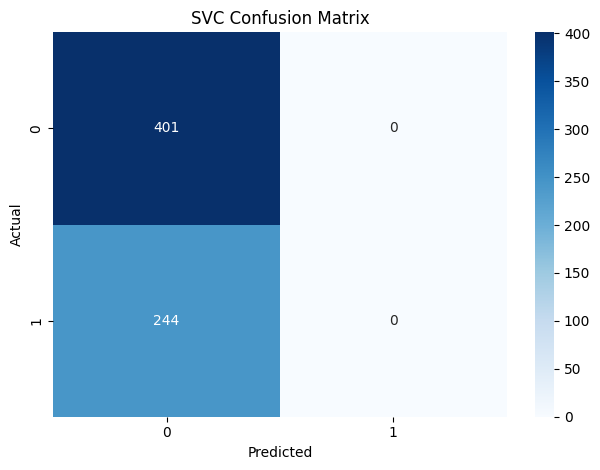

⏱ Total Training Time (seconds): 107.201
⏱ Total Training Time (minutes): 1.787

GradientBoosting Classification Report
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       401
           1       0.94      0.89      0.92       244

    accuracy                           0.94       645
   macro avg       0.94      0.93      0.94       645
weighted avg       0.94      0.94      0.94       645

Accuracy: 0.9395
F1 Score: 0.9179


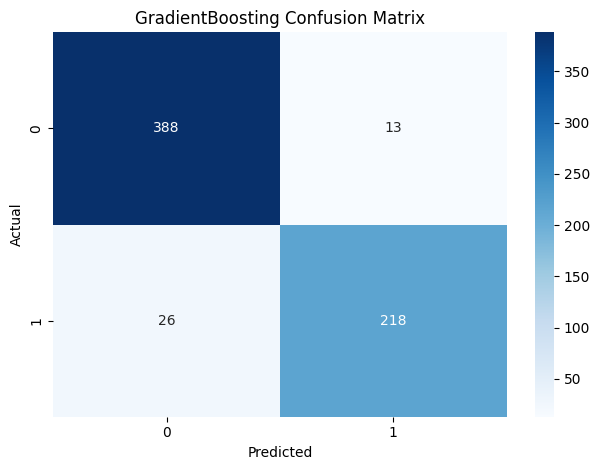

⏱ Total Training Time (seconds): 109.524
⏱ Total Training Time (minutes): 1.825

CatBoost Classification Report
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       401
           1       0.95      0.90      0.92       244

    accuracy                           0.94       645
   macro avg       0.94      0.93      0.94       645
weighted avg       0.94      0.94      0.94       645

Accuracy: 0.9426
F1 Score: 0.9221


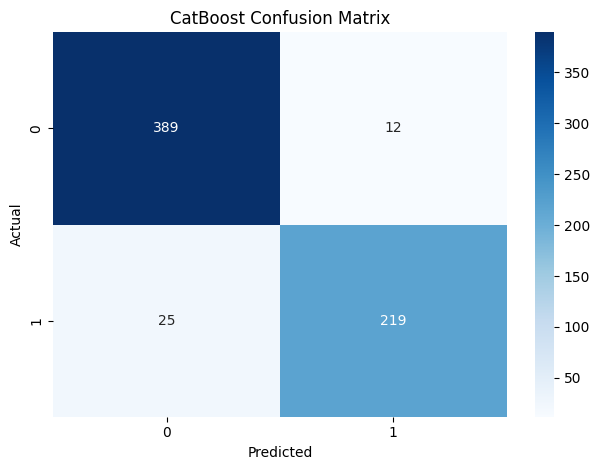

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define models
models = {
    'SVC': SVC(),  # SVM for classification
    'GradientBoosting': GradientBoostingClassifier(),
    'CatBoost': CatBoostClassifier(verbose=0)
}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    # End time
    end_time = time.time()

    print("⏱ Total Training Time (seconds):", round(end_time - start_time, 3))
    print("⏱ Total Training Time (minutes):", round((end_time - start_time)/60, 3))
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Classification Report")
    print(classification_report(y_test, y_pred))
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


## HyperParameter

Fitting 5 folds for each of 30 candidates, totalling 150 fits
⏱ Total Training Time (seconds): 802.837
⏱ Total Training Time (minutes): 13.381

Tuned CatBoost Classification Report:
Best Params: {'random_strength': 1, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 100, 'depth': 8, 'bagging_temperature': 0.2}
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       401
           1       0.95      0.89      0.92       244

    accuracy                           0.94       645
   macro avg       0.94      0.93      0.94       645
weighted avg       0.94      0.94      0.94       645

Accuracy: 0.9411
F1 Score: 0.9198


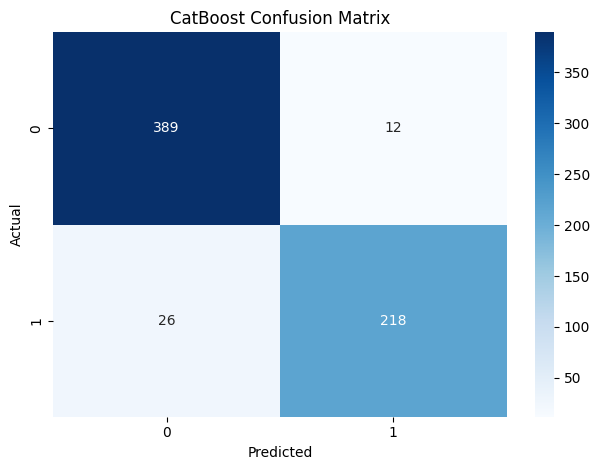

In [12]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Base classifier
catboost_clf = CatBoostClassifier(verbose=0, random_state=42)

# Hyperparameter grid
param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'iterations': [100, 300, 500, 1000],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0.2, 0.5, 1.0],
    'random_strength': [1, 5, 10]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=catboost_clf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the search
random_search.fit(X_train, y_train)
# End time
end_time = time.time()

print("⏱ Total Training Time (seconds):", round(end_time - start_time, 3))
print("⏱ Total Training Time (minutes):", round((end_time - start_time)/60, 3))

# Best model
best_model = random_search.best_estimator_

# Predict and evaluate
y_pred = best_model.predict(X_test)

# Print results
print("\nTuned CatBoost Classification Report:")
print(f"Best Params: {random_search.best_params_}")
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
⏱ Total Training Time (seconds): 886.918
⏱ Total Training Time (minutes): 14.782

Tuned Gradient Boosting Classification Report:
Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.05}
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       401
           1       0.95      0.86      0.91       244

    accuracy                           0.93       645
   macro avg       0.94      0.92      0.93       645
weighted avg       0.93      0.93      0.93       645

Accuracy: 0.9318
F1 Score: 0.9311


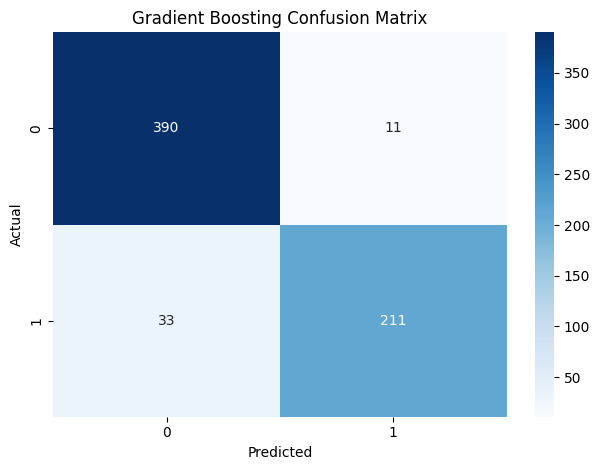

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Base model
gb_model = GradientBoostingClassifier(random_state=42)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)
# End time
end_time = time.time()

print("⏱ Total Training Time (seconds):", round(end_time - start_time, 3))
print("⏱ Total Training Time (minutes):", round((end_time - start_time)/60, 3))
best_model = random_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluation
print("\nTuned Gradient Boosting Classification Report:")
print(f"Best Params: {random_search.best_params_}")
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Base model
svc = SVC(probability=True, random_state=42)

# Hyperparameter grid
param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # Used only for 'poly' kernel
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model
start_time = time.time()
random_search.fit(X_train, y_train)
print("⏱ Total Training Time (seconds):", round(end_time - start_time, 3))
print("⏱ Total Training Time (minutes):", round((end_time - start_time)/60, 3))
end_time = time.time()

best_model = random_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluation
print("\nTuned SVC Classification Report:")
print(f"Best Params: {random_search.best_params_}")
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
